##**Importing all the necessary libraries**

In [ ]:
# Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display
from sklearn.preprocessing import StandardScaler
!pip install squarify
import squarify  # for treemap visualization

##**Setting visualization style**

In [ ]:
# Setting visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

##**Loading the cleaned data**

In [ ]:
# Load the cleaned data
# df = pd.read_csv('data/processed/online_retail_cleaned.csv') ##If the 'data' directory has been created already, import the file from this

from google.colab import files
uploaded = files.upload()
df=pd.read_csv('online_retail_cleaned.csv')

Saving online_retail_cleaned.csv to online_retail_cleaned.csv


##**Data Preprocessing**

In [ ]:
# Converting InvoiceDate back to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
# Setting the maximum date for recency calculation (one day after the last invoice date in the dataset)
max_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Reference date for recency calculation: {max_date}")

Reference date for recency calculation: 2011-12-10 12:50:00


In [ ]:
# Calculating RFM metrics for each customer
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (max_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                # Frequency
    'TotalAmount': 'sum'                                 # Monetary
})


In [ ]:
# Renaming some columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [ ]:
# Checking for any negative values in recency (which would indicate data errors)
print(f"Minimum recency value: {rfm['Recency'].min()} days")


Minimum recency value: 1 days


##**Descriptive Statistics**

In [ ]:
# Displaying summary statistics for RFM metrics
print("\nRFM Metrics Summary Statistics:")
display(rfm.describe())



RFM Metrics Summary Statistics:


,Recency,Frequency,Monetary
count,4290.000000,4290.000000,4290.000000
mean,92.574592,4.191142,1613.083600
std,99.993918,7.465179,4820.581093
min,1.000000,1.000000,2.900000
25%,18.000000,1.000000,290.210000
50%,51.000000,2.000000,637.695000
75%,143.000000,5.000000,1547.890000
max,374.000000,205.000000,158967.800000


##**Visualizing the distribution of RFM metrics**

Text(0.5, 0, 'Recency (days)')

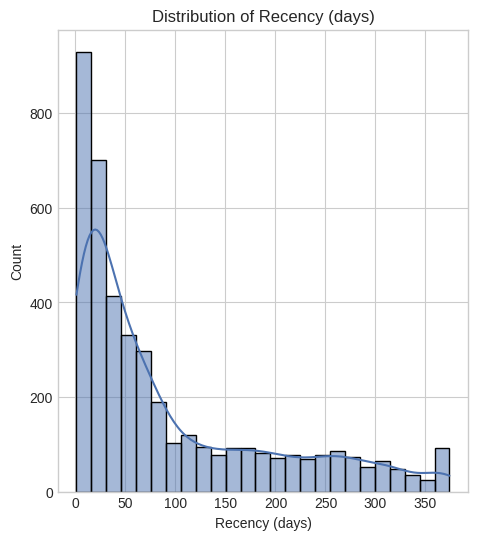

In [ ]:
# Visualizing the distribution of RFM metrics
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], kde=True)
plt.title('Distribution of Recency (days)')
plt.xlabel('Recency (days)')


(0.0, 13.0)

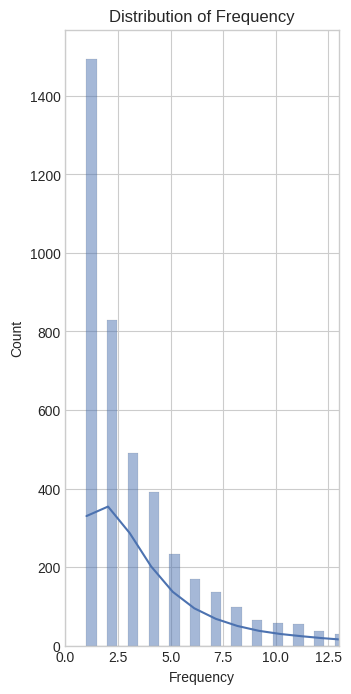

In [ ]:
plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], kde=True)
plt.title('Distribution of Frequency')
plt.xlabel('Frequency')
plt.xlim(0, rfm['Frequency'].quantile(0.95))  # Limit x-axis to 95th percentile for better visualization

(0.0, 5240.4634999999935)

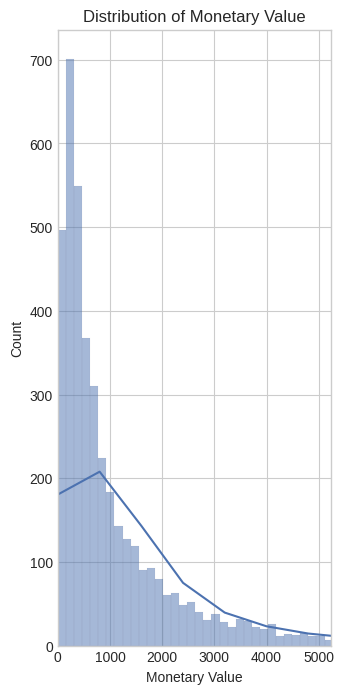

In [ ]:
plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], kde=True)
plt.title('Distribution of Monetary Value')
plt.xlabel('Monetary Value')
plt.xlim(0, rfm['Monetary'].quantile(0.95))  # Limit x-axis to 95th percentile for better visualization


In [ ]:
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

In [ ]:
# Creating RFM scores (1-5 scale where 5 is best)
# For Recency, lower is better, so reverse quantiles are used here
# For Frequency and Monetary, higher is better

# Create score bins
r_labels = range(1, 6)
f_labels = range(1, 6)
m_labels = range(1, 6)

In [ ]:
# Creating R score (higher score for lower recency)
r_bins = pd.qcut(rfm['Recency'], q=5, labels=r_labels, duplicates='drop')
if len(np.unique(r_bins)) < 5:  # Handle cases where there are duplicate values
    r_bins = pd.qcut(rfm['Recency'], q=5, labels=r_labels, duplicates='drop')
    print("Note: Using 'drop' method to handle duplicate recency values in quantiles")


In [ ]:
# # Create F score
# f_bins = pd.qcut(rfm['Frequency'], q=5, labels=f_labels, duplicates='drop')
# if len(np.unique(f_bins)) < 5:  # Handle cases where there are duplicate values
#     f_bins = pd.cut(rfm['Frequency'], bins=5, labels=f_labels)
#     print("Note: Using 'cut' instead of 'qcut' to handle duplicate frequency values")


# Creating F score
f_bins = pd.qcut(rfm['Frequency'], q=5, labels=None, duplicates='drop')  # Removing labels here
f_bins = pd.Series(pd.Categorical(f_bins, categories=f_bins.cat.categories.sort_values(), ordered=True))  #added for handling cases where f_bins is only 1 element
# Assigning labels after binning to avoid conflict
# Checking the number of unique bins and adjust labels if needed
num_unique_bins = len(f_bins.cat.categories)
if num_unique_bins < 5:
    f_labels = range(1, num_unique_bins + 1) # Adjusting labels to match the number of unique bins

f_bins = f_bins.cat.rename_categories(f_labels)  # Now rename the categories


#Handling cases where f_bins is only 1 element
if len(np.unique(f_bins)) < 5:  # Handling cases where there are duplicate values
    # Adjusting the number of bins to match the number of labels
    f_bins = pd.cut(rfm['Frequency'], bins=len(f_labels), labels=f_labels)
    print("Note: Using 'cut' instead of 'qcut' to handle duplicate frequency values")

Note: Using 'cut' instead of 'qcut' to handle duplicate frequency values


In [ ]:
# Creating M score
m_bins = pd.qcut(rfm['Monetary'], q=5, labels=m_labels, duplicates='drop')
if len(np.unique(m_bins)) < 5:  # Handle cases where there are duplicate values
    m_bins = pd.cut(rfm['Monetary'], bins=5, labels=m_labels)
    print("Note: Using 'cut' instead of 'qcut' to handle duplicate monetary values")

# Assigning scores to customers
rfm['R_Score'] = r_bins
rfm['F_Score'] = f_bins
rfm['M_Score'] = m_bins



In [ ]:
# Calculating aggregate RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)


In [ ]:
# Printing summary of RFM scores
print("\nRFM Score Distribution:")
print(rfm['RFM_Score'].value_counts().sort_index())


RFM Score Distribution:
RFM_Score
3       59
4      193
5      396
6      737
7     1374
8      928
9      444
10     145
11      14
Name: count, dtype: int64


##**Visualizing RFM score distribution**

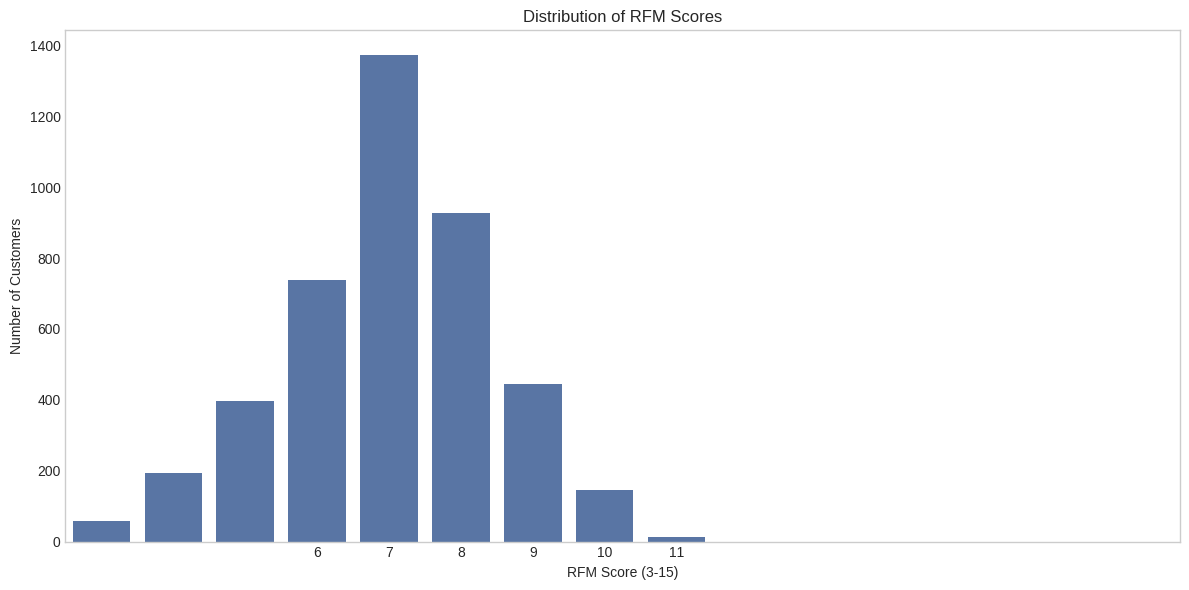

In [ ]:
# Visualizing RFM score distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='RFM_Score', data=rfm)
plt.title('Distribution of RFM Scores')
plt.xlabel('RFM Score (3-15)')
plt.ylabel('Number of Customers')
plt.xticks(range(3, 16))
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##**Creating RFM segments based on score combinations**

In [ ]:
# Creating RFM segments based on score combinations
def segment_customer(row):
    # Champions: Recent, frequent buyers with high spending
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'

    # Loyal Customers: Buy frequently with good recency but not highest spending
    elif row['F_Score'] >= 3 and (row['R_Score'] >= 3) and (row['M_Score'] >= 3):
        return 'Loyal Customers'

    # Potential Loyalists: Recent customers with average frequency and spending
    elif (row['R_Score'] >= 4) and (row['F_Score'] >= 2 and row['F_Score'] < 4) and (row['M_Score'] >= 2 and row['M_Score'] < 4):
        return 'Potential Loyalists'

    # New Customers: Recent shoppers with low frequency and spending
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2 and row['M_Score'] <= 2:
        return 'New Customers'

    # Promising: Recent shoppers with low frequency but higher spending
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2 and row['M_Score'] > 2:
        return 'Promising'

    # Need Attention: Above average recency, frequency and spending
    elif (row['R_Score'] >= 2 and row['R_Score'] < 4) and (row['F_Score'] >= 2 and row['F_Score'] < 4) and (row['M_Score'] >= 2 and row['M_Score'] < 4):
        return 'Need Attention'

    # About to Sleep: Below average recency, frequency and spending
    elif (row['R_Score'] >= 2 and row['R_Score'] < 4) and row['F_Score'] <= 2 and row['M_Score'] <= 2:
        return 'About to Sleep'

    # At Risk: Low recency but good history of frequency and spending
    elif row['R_Score'] <= 2 and (row['F_Score'] >= 2 or row['M_Score'] >= 2):
        return 'At Risk'

    # Cannot Lose Them: Low recency, high frequency and spending
    elif row['R_Score'] <= 2 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Cannot Lose Them'

    # Hibernating: Low recency, frequency and spending
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2 and row['M_Score'] <= 2:
        return 'Hibernating'

    # Lost: Lowest scores across all metrics
    elif row['R_Score'] <= 1 and row['F_Score'] <= 1 and row['M_Score'] <= 1:
        return 'Lost'

    else:
        return 'Others'


##**Applying segmentation function**

In [ ]:
# Applying segmentation function
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Counting customers in each segment
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

# Calculating the percentage of customers in each segment
segment_counts['Percentage'] = segment_counts['Count'] / segment_counts['Count'].sum() * 100

# Displaying segment distribution
print("\nCustomer Segment Distribution:")
display(segment_counts)



Customer Segment Distribution:


,Segment,Count,Percentage
0,At Risk,1454,33.892774
1,New Customers,1025,23.892774
2,Promising,690,16.083916
3,About to Sleep,551,12.843823
4,Others,511,11.911422
5,Hibernating,59,1.375291


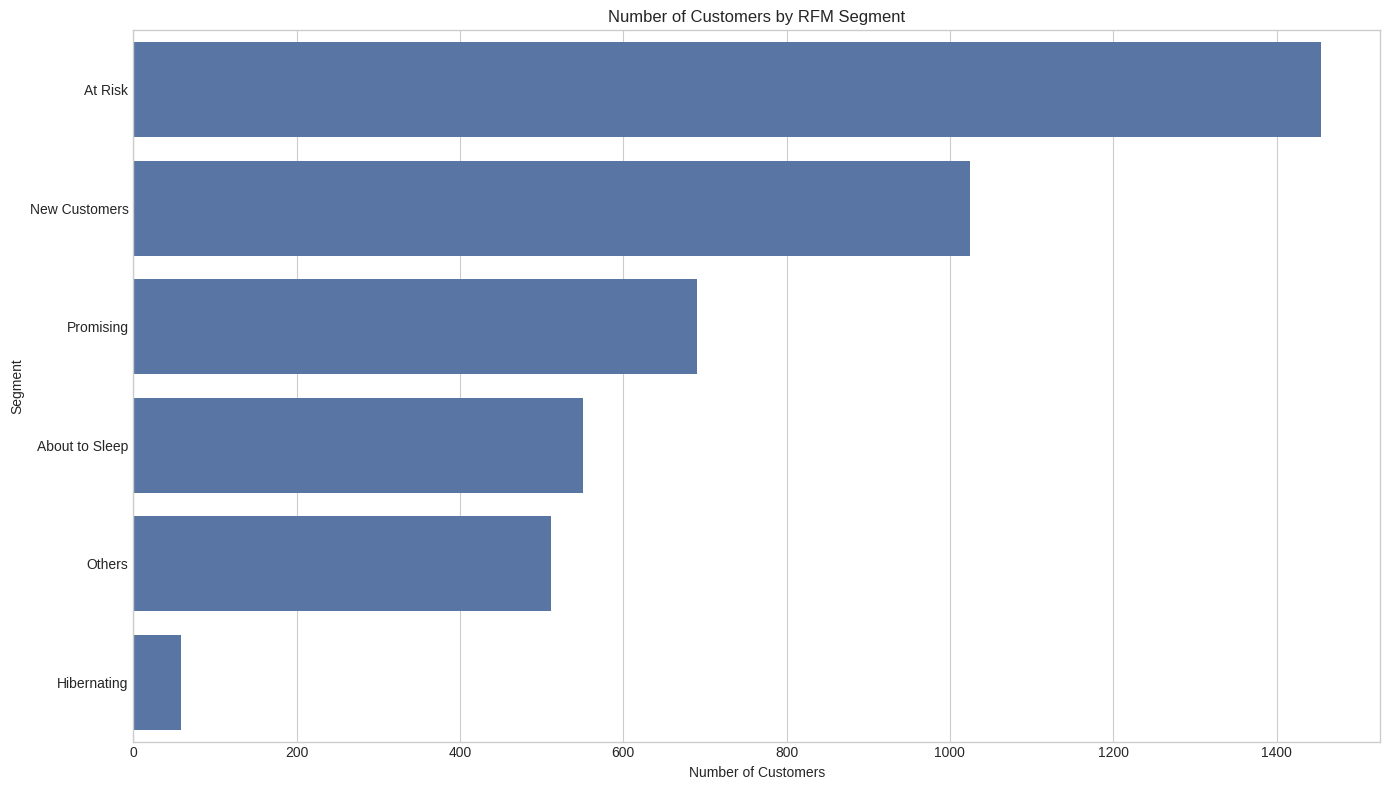

In [ ]:
# Visualizing segment distribution
plt.figure(figsize=(14, 8))
sns.barplot(x='Count', y='Segment', data=segment_counts.sort_values('Count', ascending=False))
plt.title('Number of Customers by RFM Segment')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.show()

##**Creating a treemap visualization for segment distribution**

In [ ]:
# Creating a treemap visualization for segment distribution
fig = px.treemap(segment_counts,
                path=['Segment'],
                values='Count',
                color='Count',
                hover_data=['Percentage'],
                color_continuous_scale='Viridis')

fig.update_layout(title='Customer Segments Treemap')
fig.show()

##**Analyzing RFM metrics by segment**

In [ ]:
# Analyzing RFM metrics by segment
segment_rfm = rfm.reset_index().groupby('Segment').agg({ # Reset index to make 'Customer ID' a column
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'RFM_Score': 'mean',
    'Customer ID': 'count'  # Now you can aggregate 'Customer ID'
}).reset_index()

##**Calculating average metrics across all customers**

In [ ]:
segment_rfm.columns = ['Segment', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Avg_RFM_Score', 'Customer_Count']
segment_rfm = segment_rfm.sort_values('Avg_RFM_Score', ascending=False)

In [ ]:
# Calculating average metrics across all customers
avg_metrics = {
    'Avg_Recency': rfm['Recency'].mean(),
    'Avg_Frequency': rfm['Frequency'].mean(),
    'Avg_Monetary': rfm['Monetary'].mean()
}

##**Displaying segment analysis**

In [ ]:
# Displaying segment analysis
print("\nRFM Metrics by Segment:")
display(segment_rfm)



RFM Metrics by Segment:


,Segment,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_RFM_Score,Customer_Count
5,Promising,155.391304,2.917391,1194.986945,8.920290,690
4,Others,51.150685,4.103718,1640.212407,7.886497,511
3,New Customers,216.104390,1.310244,228.528381,7.095610,1025
1,At Risk,13.709766,8.007565,3352.836383,6.566713,1454
0,About to Sleep,39.793103,1.430127,252.210200,5.099819,551
2,Hibernating,7.118644,1.627119,156.027119,3.000000,59


##**Completing the radar chart function**

In [ ]:
# Completing the radar chart function
def plot_radar_chart(segment_rfm, segments_to_plot):
    # Selecting specific segments to compare
    plot_data = segment_rfm[segment_rfm['Segment'].isin(segments_to_plot)].copy()

    # Normalized the metrics for radar chart
    scaler = StandardScaler()
    metrics = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']

    # For radar chart, higher values are required to be better
    # So recency is flipped (lower is better originally)
    plot_data['Avg_Recency_Inverse'] = plot_data['Avg_Recency'].max() - plot_data['Avg_Recency']

    normalized_data = pd.DataFrame(
        scaler.fit_transform(plot_data[['Avg_Recency_Inverse', 'Avg_Frequency', 'Avg_Monetary']]),
        columns=['Recency', 'Frequency', 'Monetary']
    )

    # Adding segment names back
    normalized_data['Segment'] = plot_data['Segment'].values

    # Radar chart using plotly
    fig = go.Figure()

    # Added traces for each segment
    for segment in normalized_data['Segment'].unique():
        segment_data = normalized_data[normalized_data['Segment'] == segment]
        fig.add_trace(go.Scatterpolar(
            r=[segment_data['Recency'].values[0], segment_data['Frequency'].values[0],
               segment_data['Monetary'].values[0], segment_data['Recency'].values[0]],  # Close the loop
            theta=['Recency', 'Frequency', 'Monetary', 'Recency'],
            fill='toself',
            name=segment
        ))

    # Updated the layout
    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 3]  # Standardized data typically falls within -3 to +3
            )
        ),
        title="Comparison of Customer Segments",
        showlegend=True
    )

    return fig

##**Comparing key segments using radar chart**

In [ ]:

# Compared key segments using radar chart
# Select top segments to compare
key_segments = ['Champions', 'Loyal Customers', 'At Risk', 'Cannot Lose Them', 'New Customers']
radar_fig = plot_radar_chart(segment_rfm, key_segments)
radar_fig.show()

# Compared another set of segments
other_segments = ['Potential Loyalists', 'Need Attention', 'Hibernating', 'Promising', 'About to Sleep']
radar_fig2 = plot_radar_chart(segment_rfm, other_segments)
radar_fig2.show()

##**Heatmap of RFM scores by segment**

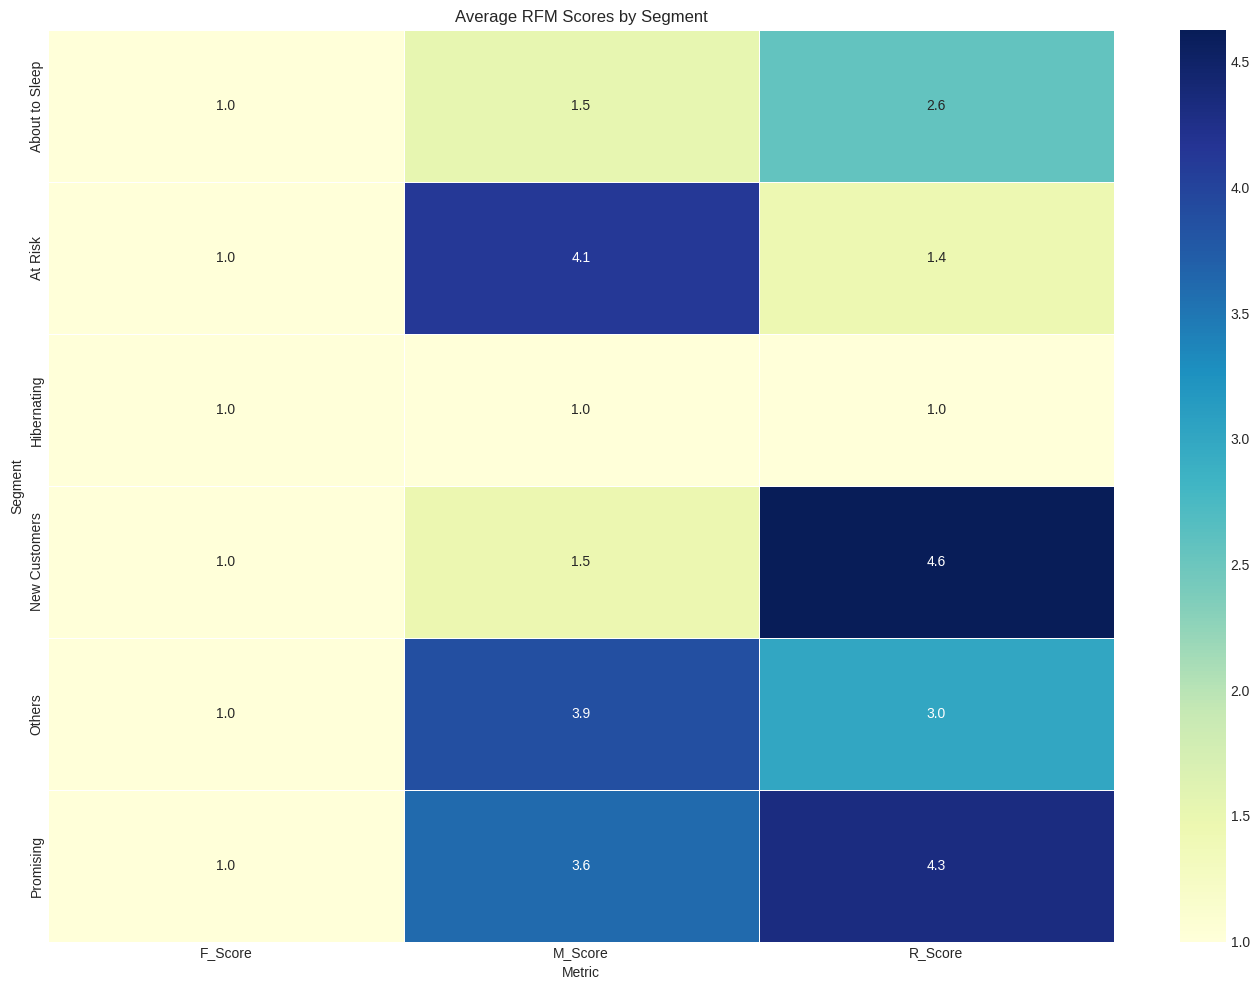

In [ ]:
# Heatmap of RFM scores by segment
plt.figure(figsize=(14, 10))

# Converting RFM scores to numeric before calculating the mean
segment_scores = rfm.groupby('Segment')[['R_Score', 'F_Score', 'M_Score']].agg(lambda x: x.astype(int).mean()).reset_index()
segment_scores = segment_scores.sort_values('Segment')

# Creating a pivot table for the heatmap
segment_scores_pivot = segment_scores.melt(id_vars=['Segment'],
                                         value_vars=['R_Score', 'F_Score', 'M_Score'],
                                         var_name='Metric', value_name='Score')
segment_scores_pivot = segment_scores_pivot.pivot(index='Segment', columns='Metric', values='Score')

# Plotting heatmap
sns.heatmap(segment_scores_pivot, annot=True, cmap='YlGnBu', fmt='.1f', linewidths=.5)
plt.title('Average RFM Scores by Segment')
plt.tight_layout()
plt.show()

##**Customer value and segment size visualization**

In [ ]:
# Customer value and segment size visualization
plt.figure(figsize=(14, 8))
value_size = segment_rfm.copy()
value_size['Total_Value'] = value_size['Avg_Monetary'] * value_size['Customer_Count']
value_size['Percentage_Value'] = value_size['Total_Value'] / value_size['Total_Value'].sum() * 100
value_size['Customer_Percentage'] = value_size['Customer_Count'] / value_size['Customer_Count'].sum() * 100
value_size = value_size.sort_values('Total_Value', ascending=False)

<Figure size 1400x800 with 0 Axes>

Text(0, 0.5, 'Total Monetary Value')

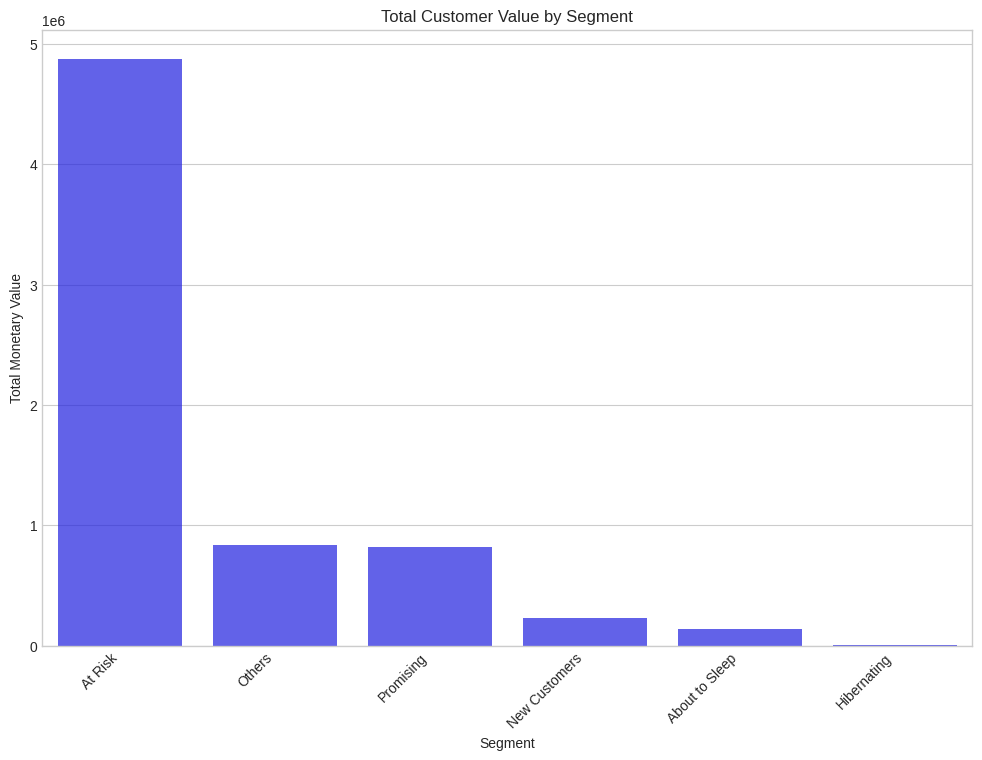

In [ ]:
# Bar chart with two metrics
ax = sns.barplot(x='Segment', y='Total_Value', data=value_size, color='blue', alpha=0.7)
plt.title('Total Customer Value by Segment')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Monetary Value')

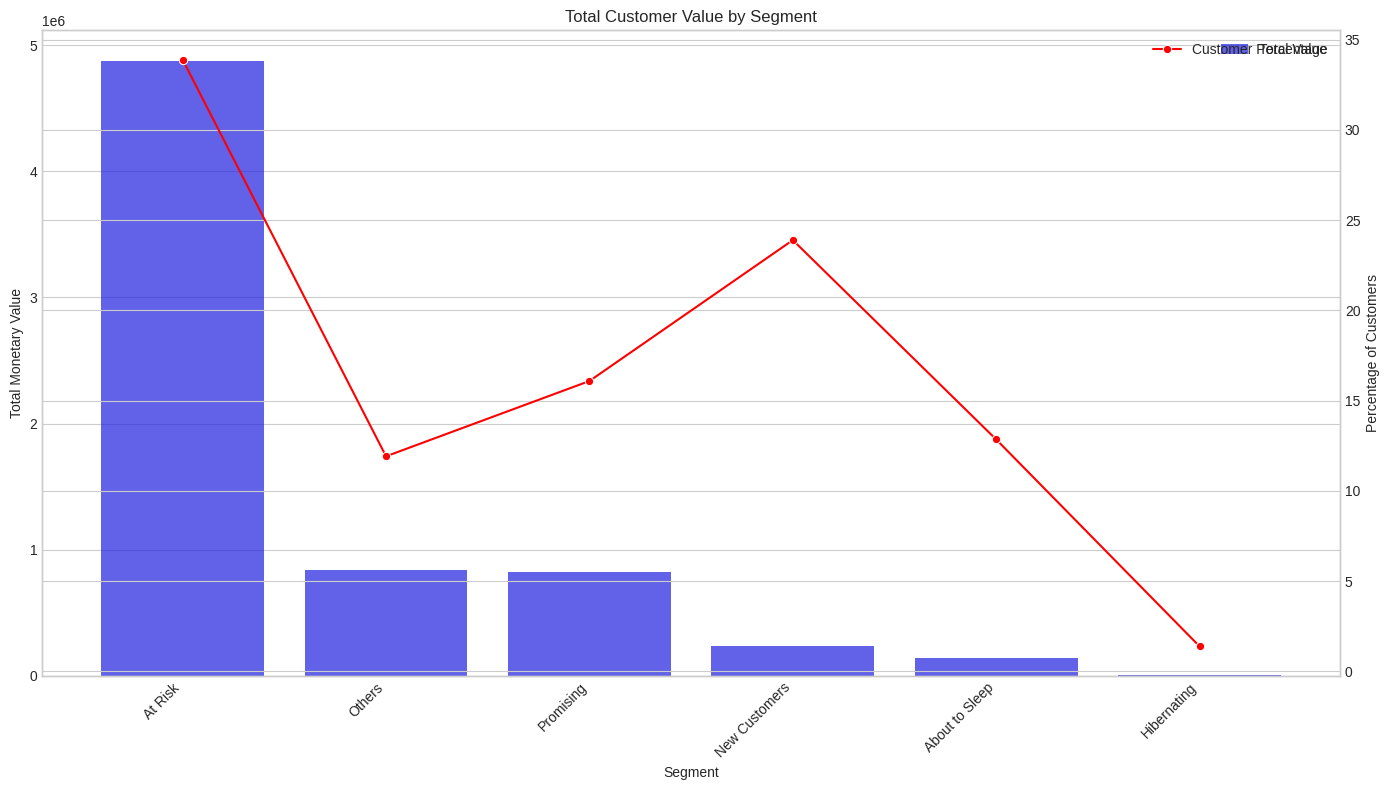

In [ ]:
# Customer value and segment size visualization
plt.figure(figsize=(14, 8))
value_size = segment_rfm.copy()
value_size['Total_Value'] = value_size['Avg_Monetary'] * value_size['Customer_Count']
value_size['Percentage_Value'] = value_size['Total_Value'] / value_size['Total_Value'].sum() * 100
value_size['Customer_Percentage'] = value_size['Customer_Count'] / value_size['Customer_Count'].sum() * 100
value_size = value_size.sort_values('Total_Value', ascending=False)

# Bar chart with two metrics
# *** Add the 'label' argument here ***
ax = sns.barplot(x='Segment', y='Total_Value', data=value_size, color='blue', alpha=0.7, label='Total Value')
plt.title('Total Customer Value by Segment')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Monetary Value')

# Creating a second y-axis for percentage of customers
ax2 = ax.twinx()
# *** Add the 'label' argument here ***
sns.lineplot(x=range(len(value_size)), y='Customer_Percentage', data=value_size,
             color='red', marker='o', ax=ax2, label='Customer Percentage')
ax2.set_ylabel('Percentage of Customers')

# *** Calling the legend directly on the axes with plotted elements ***
ax.legend() # Or ax.legend(loc='upper left') for specific placement


plt.tight_layout()
plt.show()

##**Marketing strategy recommendations by segment**

In [ ]:
# Marketing strategy recommendations by segment
marketing_strategies = {
    'Champions': [
        'Reward them', 'Make them feel valued', 'Ask for reviews',
        'Offer exclusive loyalty rewards', 'Seek their feedback on new products'
    ],
    'Loyal Customers': [
        'Increase engagement', 'Up-sell higher value products',
        'Cross-sell complementary products', 'Invite to loyalty program'
    ],
    'Potential Loyalists': [
        'Offer membership or loyalty program', 'Recommend popular products',
        'Personalized email campaigns', 'Offer free shipping'
    ],
    'New Customers': [
        'Welcome series', 'Provide onboarding support', 'Educational content',
        'First purchase incentives', 'Request feedback'
    ],
    'Promising': [
        'Special discount on second purchase', 'Personalized recommendations',
        'Educational content', 'Premium product offers'
    ],
    'Need Attention': [
        'Reactivation campaigns', 'Limited-time offers', 'Product recommendations',
        'Bring-back incentives', 'Gather feedback'
    ],
    'About to Sleep': [
        'Reactivation campaign', 'Product recommendations based on past purchases',
        'Limited time offers', 'Remind of benefits'
    ],
    'At Risk': [
        'Win-back campaigns', 'Special discounts', 'Personalized recommendations',
        'Request feedback', 'Showcase new products'
    ],
    'Cannot Lose Them': [
        'Aggressive win-back campaign', 'One-on-one outreach', 'Special loyalty offers',
        'Create sense of urgency', 'Provide incentives'
    ],
    'Hibernating': [
        'Reactivation campaign', 'Revive interest with new products', 'Major discounts',
        'Rebuild relationship with targeted content'
    ],
    'Lost': [
        'Revive interest with relevant products', 'Major discount or incentive',
        'Reconnect via different channel', 'Understand reasons for leaving'
    ]
}

##**Displaying marketing strategies for each segment**

In [ ]:
# Displaying marketing strategies for each segment
print("\n=== RECOMMENDED MARKETING STRATEGIES BY SEGMENT ===\n")
for segment, strategies in marketing_strategies.items():
    if segment in segment_rfm['Segment'].values:
        segment_data = segment_rfm[segment_rfm['Segment'] == segment].iloc[0]
        print(f"{segment} (Customers: {segment_data['Customer_Count']}, Avg. Value: ${segment_data['Avg_Monetary']:.2f}):")
        for i, strategy in enumerate(strategies, 1):
            print(f"  {i}. {strategy}")
        print()



=== RECOMMENDED MARKETING STRATEGIES BY SEGMENT ===

New Customers (Customers: 1025, Avg. Value: $228.53):
  1. Welcome series
  2. Provide onboarding support
  3. Educational content
  4. First purchase incentives
  5. Request feedback

Promising (Customers: 690, Avg. Value: $1194.99):
  1. Special discount on second purchase
  2. Personalized recommendations
  3. Educational content
  4. Premium product offers

About to Sleep (Customers: 551, Avg. Value: $252.21):
  1. Reactivation campaign
  2. Product recommendations based on past purchases
  3. Limited time offers
  4. Remind of benefits

At Risk (Customers: 1454, Avg. Value: $3352.84):
  1. Win-back campaigns
  2. Special discounts
  3. Personalized recommendations
  4. Request feedback
  5. Showcase new products

Hibernating (Customers: 59, Avg. Value: $156.03):
  1. Reactivation campaign
  2. Revive interest with new products
  3. Major discounts
  4. Rebuild relationship with targeted content



##**Saving the RFM data and segments for use in future analyses**

In [ ]:
# Saving the RFM data and segments for use in future analyses
import os
os.makedirs('data/processed', exist_ok=True)
rfm.to_csv('data/processed/rfm_data.csv')
files.download('data/processed/rfm_data.csv')
print("\nRFM data and customer segments saved to 'data/processed/rfm_data.csv'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


RFM data and customer segments saved to 'data/processed/rfm_data.csv'


##**Final summary of the RFM analysis**

In [ ]:
# Final summary of the RFM analysis
print("\n=== RFM ANALYSIS SUMMARY ===")
print(f"Total number of customers analyzed: {len(rfm)}")
print(f"Number of customer segments identified: {len(segment_counts)}")
print(f"Top segment by customer count: {segment_counts.sort_values('Count', ascending=False)['Segment'].iloc[0]} ({segment_counts.sort_values('Count', ascending=False)['Count'].iloc[0]} customers)")
print(f"Top segment by average monetary value: {segment_rfm.sort_values('Avg_Monetary', ascending=False)['Segment'].iloc[0]} (${segment_rfm.sort_values('Avg_Monetary', ascending=False)['Avg_Monetary'].iloc[0]:.2f})")
print(f"Top segment by RFM score: {segment_rfm.sort_values('Avg_RFM_Score', ascending=False)['Segment'].iloc[0]} (Score: {segment_rfm.sort_values('Avg_RFM_Score', ascending=False)['Avg_RFM_Score'].iloc[0]:.2f})")

print("\nKey findings:")
print("1. Customer segments with high monetary value but low recency (At Risk, Cannot Lose Them) represent significant revenue recovery opportunities")
print("2. New Customers and Potential Loyalists need nurturing to increase their lifetime value")
print("3. Champions and Loyal Customers should be leveraged for reviews, referrals, and feedback")
print("4. About to Sleep and Need Attention segments require immediate re-engagement efforts")
print("5. Hibernating and Lost segments may need targeted offers to determine if they can be reactivated")

print("\nNext steps:")
print("1. Implement targeted marketing strategies for each segment")
print("2. Set up regular monitoring of segment transitions")
print("3. Develop more advanced customer segmentation using clustering techniques")
print("4. Create churn prediction models to identify at-risk customers earlier")
print("5. Calculate customer lifetime value by segment to prioritize marketing efforts")


=== RFM ANALYSIS SUMMARY ===
Total number of customers analyzed: 4290
Number of customer segments identified: 6
Top segment by customer count: At Risk (1454 customers)
Top segment by average monetary value: At Risk ($3352.84)
Top segment by RFM score: Promising (Score: 8.92)

Key findings:
1. Customer segments with high monetary value but low recency (At Risk, Cannot Lose Them) represent significant revenue recovery opportunities
2. New Customers and Potential Loyalists need nurturing to increase their lifetime value
3. Champions and Loyal Customers should be leveraged for reviews, referrals, and feedback
4. About to Sleep and Need Attention segments require immediate re-engagement efforts
5. Hibernating and Lost segments may need targeted offers to determine if they can be reactivated

Next steps:
1. Implement targeted marketing strategies for each segment
2. Set up regular monitoring of segment transitions
3. Develop more advanced customer segmentation using clustering techniques
4.

##**RFM ANALYSIS SUMMARY**
Total number of customers analyzed: 4290
Number of customer segments identified: 6
Top segment by customer count: At Risk (1454 customers)
Top segment by average monetary value: At Risk ($3352.84)
Top segment by RFM score: Promising (Score: 8.92)

Key findings:
1. Customer segments with high monetary value but low recency (At Risk, Cannot Lose Them) represent significant revenue recovery opportunities
2. New Customers and Potential Loyalists need nurturing to increase their lifetime value
3. Champions and Loyal Customers should be leveraged for reviews, referrals, and feedback
4. About to Sleep and Need Attention segments require immediate re-engagement efforts
5. Hibernating and Lost segments may need targeted offers to determine if they can be reactivated

Next steps:
1. Implement targeted marketing strategies for each segment
2. Set up regular monitoring of segment transitions
3. Develop more advanced customer segmentation using clustering techniques
4. Create churn prediction models to identify at-risk customers earlier
5. Calculate customer lifetime value by segment to prioritize marketing efforts
